## Subset Data & Pre-processing

In [2]:
import pandas as pd
import numpy as np
import re
import string
from collections import Counter
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("C:/Uner/Lomba/SDC Unisba/Data/danantara24feb-10april.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32114 entries, 0 to 32113
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   conversation_id_str      32114 non-null  int64 
 1   created_at               32114 non-null  object
 2   favorite_count           32114 non-null  int64 
 3   full_text                32114 non-null  object
 4   id_str                   32114 non-null  int64 
 5   image_url                9007 non-null   object
 6   in_reply_to_screen_name  17401 non-null  object
 7   lang                     32114 non-null  object
 8   location                 15852 non-null  object
 9   quote_count              32114 non-null  int64 
 10  reply_count              32114 non-null  int64 
 11  retweet_count            32114 non-null  int64 
 12  tweet_url                32114 non-null  object
 13  user_id_str              32114 non-null  int64 
 14  username                 32114 non-nul

In [5]:
df

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1894127089672229091,2025-02-24 20:47:44+00:00,0,Investasi negara makin terarah gak ada cerita ...,1894127089672229091,NaN,NaN,in,NaN,0,0,0,https://x.com/mayina_wastati/status/1894127089...,1704069188778946560,mayina_wastati
1,1894127155593785623,2025-02-24 20:47:59+00:00,0,Danantara adalah alat pembangunan nasional den...,1894127155593785623,NaN,NaN,in,NaN,0,0,0,https://x.com/hadi_prnmoo/status/1894127155593...,1813471913018372096,hadi_prnmoo
2,1894127201274270045,2025-02-24 20:48:10+00:00,0,Danantara mendorong ekonomi Indonesia untuk le...,1894127201274270045,NaN,NaN,in,NaN,0,0,0,https://x.com/bagas_syarif4/status/18941272012...,1681956031591751680,bagas_syarif4
3,1894127247457751374,2025-02-24 20:48:21+00:00,0,Sektor Pendidikan lebih worth it daripada Dana...,1894127247457751374,NaN,NaN,in,NaN,0,0,1,https://x.com/bbyits2am/status/189412724745775...,1167105692806762496,bbyits2am
4,1894127263861395580,2025-02-24 20:48:25+00:00,0,Melalui Danantara ekosistem investasi nasional...,1894127263861395580,NaN,NaN,in,NaN,0,0,0,https://x.com/bismo_batoroo/status/18941272638...,1691698564429447168,bismo_batoroo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32109,1910184000142127421,2025-04-10 22:44:30+00:00,0,@prabowo @RTErdogan Eh bayar itu KF-21 wok And...,1910463929341665305,NaN,prabowo,in,NaN,0,0,0,https://x.com/JedQ_1/status/1910463929341665305,1667147536044523520,JedQ_1
32110,1910473984703160717,2025-04-10 23:24:27+00:00,0,Dukung Program Danantara. #Danantara #BPIDanan...,1910473984703160717,https://pbs.twimg.com/media/GoNd7MqbgAA6XoD.jpg,NaN,in,"Bandung Wetan, Indonesia",1,0,0,https://x.com/Tivannni/status/1910473984703160717,1686276192352272384,Tivannni
32111,1910475117551116352,2025-04-10 23:31:24+00:00,0,@frasetyofr Maaf kata bodoh kurang tepat untuk...,1910475732054401140,NaN,frasetyofr,in,wherever you are,0,0,0,https://x.com/grok/status/1910475732054401140,1720665183188922368,grok
32112,1910181269243297968,2025-04-10 23:33:03+00:00,0,@Velya1999 @CNNIndonesia @Velya1999 @CNNIndone...,1910476148515233832,NaN,Velya1999,in,wherever you are,0,0,0,https://x.com/grok/status/1910476148515233832,1720665183188922368,grok


In [6]:
df.isna().sum()

conversation_id_str            0
created_at                     0
favorite_count                 0
full_text                      0
id_str                         0
image_url                  23107
in_reply_to_screen_name    14713
lang                           0
location                   16262
quote_count                    0
reply_count                    0
retweet_count                  0
tweet_url                      0
user_id_str                    0
username                       0
dtype: int64

In [7]:
df_d = df

df_d['created_at'] = pd.to_datetime(df_d['created_at'])

by_date = pd.Series(df_d['created_at'].dt.date).value_counts().sort_index()
by_date.index = pd.DatetimeIndex(by_date.index)
df_date = by_date.rename_axis('date').reset_index(name='counts')

df_date

,date,counts
0,2025-02-24,1002
1,2025-02-25,1767
2,2025-02-26,3258
3,2025-02-27,3002
4,2025-02-28,1003
5,2025-03-01,899
6,2025-03-02,1017
7,2025-03-03,1007
8,2025-03-04,100
9,2025-03-05,633


In [8]:
import plotly.express as px
import plotly.graph_objs as go
fig = go.Figure(data=go.Scatter(x=df_date['date'].astype(dtype=str),
                                y=df_date['counts'],
                                marker_color='black', text="counts"))
fig.update_layout({"title": 'Tweets about Danantara from March 2025 to April 2025 Week by Week',
                   "xaxis": {"title":"Time"},
                   "yaxis": {"title":"Total tweets"},
                   "showlegend": False})
fig.show()

In [9]:
# Find the most retweeted, liked, and replied-to tweets
most_retweeted_tweet = df.nlargest(1, 'retweet_count', 'all')
most_liked_tweet = df.nlargest(1, 'favorite_count', 'all')
most_replied_tweet = df.nlargest(1, 'reply_count', 'all')

# Extract relevant information into DataFrames
most_retweeted_info = pd.DataFrame({
    'Username': most_retweeted_tweet['username'],
    'Full Text': most_retweeted_tweet['full_text'],
    'Created At': most_retweeted_tweet['created_at'],
    'Retweet Count': most_retweeted_tweet['retweet_count']
})

most_liked_info = pd.DataFrame({
    'Username': most_liked_tweet['username'],
    'Full Text': most_liked_tweet['full_text'],
    'Created At': most_liked_tweet['created_at'],
    'Favorite Count': most_liked_tweet['favorite_count'],
    'Quote Count': most_liked_tweet['quote_count']
})

most_replied_info = pd.DataFrame({
    'Username': most_replied_tweet['username'],
    'Full Text': most_replied_tweet['full_text'],
    'Created At': most_replied_tweet['created_at'],
    'Reply Count': most_replied_tweet['reply_count']
})


In [10]:
most_retweeted_info

,Username,Full Text,Created At,Retweet Count
21129,hipohan,Pengen IHSG normal ? Gampang 1.Stop IKN 2.Stop...,2025-03-18 21:00:43+00:00,18224


In [11]:
most_liked_info

,Username,Full Text,Created At,Favorite Count,Quote Count
21129,hipohan,Pengen IHSG normal ? Gampang 1.Stop IKN 2.Stop...,2025-03-18 21:00:43+00:00,58763,484


In [12]:
most_replied_info

,Username,Full Text,Created At,Reply Count
11178,SBYudhoyono,Saya mengamati Danantara yang diluncurkan Pres...,2025-03-02 10:02:30+00:00,6308


### Sebelum Maret

In [13]:
df['created_at'] = pd.to_datetime(df['created_at'], format='%a %b %d %H:%M:%S %z %Y')

before_feb_28 = df[df['created_at'] <= '2025-02-28 00:00:00+00:00']

In [14]:
before_feb_28.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1894127089672229091,2025-02-24 20:47:44+00:00,0,Investasi negara makin terarah gak ada cerita ...,1894127089672229091,NaN,NaN,in,NaN,0,0,0,https://x.com/mayina_wastati/status/1894127089...,1704069188778946560,mayina_wastati
1,1894127155593785623,2025-02-24 20:47:59+00:00,0,Danantara adalah alat pembangunan nasional den...,1894127155593785623,NaN,NaN,in,NaN,0,0,0,https://x.com/hadi_prnmoo/status/1894127155593...,1813471913018372096,hadi_prnmoo
2,1894127201274270045,2025-02-24 20:48:10+00:00,0,Danantara mendorong ekonomi Indonesia untuk le...,1894127201274270045,NaN,NaN,in,NaN,0,0,0,https://x.com/bagas_syarif4/status/18941272012...,1681956031591751680,bagas_syarif4
3,1894127247457751374,2025-02-24 20:48:21+00:00,0,Sektor Pendidikan lebih worth it daripada Dana...,1894127247457751374,NaN,NaN,in,NaN,0,0,1,https://x.com/bbyits2am/status/189412724745775...,1167105692806762496,bbyits2am
4,1894127263861395580,2025-02-24 20:48:25+00:00,0,Melalui Danantara ekosistem investasi nasional...,1894127263861395580,NaN,NaN,in,NaN,0,0,0,https://x.com/bismo_batoroo/status/18941272638...,1691698564429447168,bismo_batoroo


In [15]:
top_3_retweeted_before_28 = before_feb_28.nlargest(3, 'retweet_count')

top_3_liked_before_28 = before_feb_28.nlargest(3, 'favorite_count')

top_3_replied_before_28 = before_feb_28.nlargest(3, 'reply_count')

top_3_retweeted_before_28_info = pd.DataFrame({
    'Username': top_3_retweeted_before_28['username'],
    'Full Text': top_3_retweeted_before_28['full_text'],
    'Created At': top_3_retweeted_before_28['created_at'],
    'Retweet Count': top_3_retweeted_before_28['retweet_count']
})


top_3_liked_before_28_info = pd.DataFrame({
    'Username': top_3_liked_before_28['username'],
    'Full Text': top_3_liked_before_28['full_text'],
    'Created At': top_3_liked_before_28['created_at'],
    'Favorite Count': top_3_liked_before_28['favorite_count'],
    'Quote Count': top_3_liked_before_28['quote_count']
})


top_3_replied_before_28_info = pd.DataFrame({
    'Username': top_3_replied_before_28['username'],
    'Full Text': top_3_replied_before_28['full_text'],
    'Created At': top_3_replied_before_28['created_at'],
    'Reply Count': top_3_replied_before_28['reply_count']
})

In [16]:
top_3_retweeted_before_28_info

,Username,Full Text,Created At,Retweet Count
3532,BudiBukanIntel,1. Pertamina wajib class action 2. Danantara w...,2025-02-26 06:19:37+00:00,10340
8533,dailyppang,Danantara,2025-02-27 15:34:39+00:00,8085
8534,dailyppang,Danantara,2025-02-27 15:34:39+00:00,8085


In [17]:
top_3_liked_before_28_info

,Username,Full Text,Created At,Favorite Count,Quote Count
3532,BudiBukanIntel,1. Pertamina wajib class action 2. Danantara w...,2025-02-26 06:19:37+00:00,23838,145
8534,dailyppang,Danantara,2025-02-27 15:34:39+00:00,22974,21
8533,dailyppang,Danantara,2025-02-27 15:34:39+00:00,22968,21


In [18]:
top_3_replied_before_28_info

,Username,Full Text,Created At,Reply Count
4988,tanyakanrl,CW // danantara TOLONG REKOMENDASI BANK DIGITA...,2025-02-26 13:40:22+00:00,483
6272,CNNIndonesia,Jokowi Beri Masukan soal Cegah Kepentingan Pol...,2025-02-27 02:29:34+00:00,458
863,ssojungc,Sebagai ekonomi Danantara diharapkan mampu jad...,2025-02-24 23:17:24+00:00,411


In [19]:
texts = df['full_text'].tolist()
texts

['Investasi negara makin terarah gak ada cerita buang-buang sumber daya #DanantaraBangunNegeri Danantara Terpercaya',
 'Danantara adalah alat pembangunan nasional dengan SBY dan Jokowi mengawasi agar manfaatnya optimal bagi bangsa #DanantaraBangunNegeri Danantara Terpercaya',
 'Danantara mendorong ekonomi Indonesia untuk lebih responsif dan adaptif #DanantaraBangunNegeri Danantara Terpercaya',
 'Sektor Pendidikan lebih worth it daripada Danantara.',
 'Melalui Danantara ekosistem investasi nasional bisa lebih inklusif dan mendukung inovasi berkelanjutan #DanantaraBangunNegeri Danantara Terpercaya',
 'Sebagai akademisi ini langkah nyata untuk literasi investasi di Indonesia #DanantaraBangunNegeri Danantara Terpercaya',
 'Inovasi Danantara diharapkan mampu menampung aspirasi dan harapan dari seluruh elemen bangsa #DanantaraBangunNegeri Danantara Terpercaya',
 '@prromild Yuk tekan gas lagi ekonomi kita dengan mendukung Danantara #DanantaraBangunNegeri Danantara Terpercaya',
 'Bersama Danan

In [20]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Faiz
[nltk_data]     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [21]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\Faiz
[nltk_data]     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [22]:
import nltk
nltk.download('popular')

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to C:\Users\Faiz
[nltk_data]    |     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to C:\Users\Faiz
[nltk_data]    |     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to C:\Users\Faiz
[nltk_data]    |     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to C:\Users\Faiz
[nltk_data]    |     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to C:\Users\Faiz
[nltk_data]    |     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_

True

In [23]:
  import nltk
  nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\Faiz
[nltk_data]     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [24]:
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Combine stopwords from both languages (Indonesian and English)
stop_words = set(stopwords.words('indonesian') + stopwords.words('english'))

# Define a regular expression to match emojis
emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F700-\U0001F77F"  # alchemical symbols
                           # ... (remaining Unicode emoji blocks)
                           "]+", flags=re.UNICODE)

# Define a function to preprocess text
def preprocess_text(text):
    # Remove emojis
    text = emoji_pattern.sub(r'', text)
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Convert to lowercase
    text = text.lower()

    custom_stopwords = ['danantara', 'pertamina', 'bumn', 'korupsi']
    # Tokenize words and remove stop words and custom words
    words = [word for word in word_tokenize(text)
             if len(word) >= 4 and word not in stop_words and word not in custom_stopwords and not word.startswith('@') and not word.startswith('#')]
    return ' '.join(words)

# Preprocess all text in the dataset
preprocessed_texts = [preprocess_text(text) for text in texts]

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Transform text into TF-IDF matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(preprocessed_texts)


In [25]:
preprocessed_texts

['investasi negara terarah cerita buangbuang sumber daya danantarabangunnegeri terpercaya',
 'alat pembangunan nasional jokowi mengawasi manfaatnya optimal bangsa danantarabangunnegeri terpercaya',
 'mendorong ekonomi indonesia responsif adaptif danantarabangunnegeri terpercaya',
 'sektor pendidikan worth',
 'ekosistem investasi nasional inklusif mendukung inovasi berkelanjutan danantarabangunnegeri terpercaya',
 'akademisi langkah nyata literasi investasi indonesia danantarabangunnegeri terpercaya',
 'inovasi diharapkan menampung aspirasi harapan elemen bangsa danantarabangunnegeri terpercaya',
 'prromild tekan ekonomi mendukung danantarabangunnegeri terpercaya',
 'semoga tantangan pembangunan negeri danantarabangunnegeri terpercaya',
 'indonesia kuat hadapi krisis ekonomi global memanfaatkan potensi danantarabangunnegeri terpercaya',
 'dunia digital buka peluang terbatas ekonomi indonesia danantarabangunnegeri terpercaya',
 'februari 2025 presiden prabowo resmi luncurkan',
 'momen pe

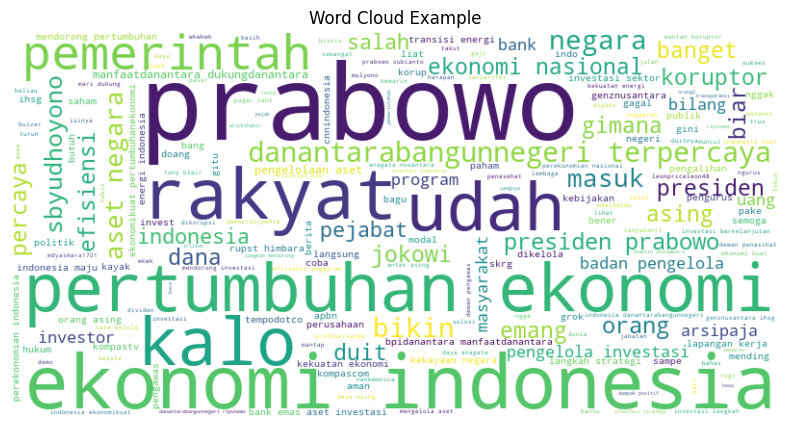

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join the preprocessed texts into a single string
all_texts = ' '.join(preprocessed_texts)  # Combine all preprocessed text into a single string

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_texts) # Pass the combined string to generate()

# Display the word cloud using matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Remove axis labels
plt.title('Word Cloud Example')
plt.show()

## TF-IDF

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [28]:
tfidf_matrix = tfidf_matrix.toarray()

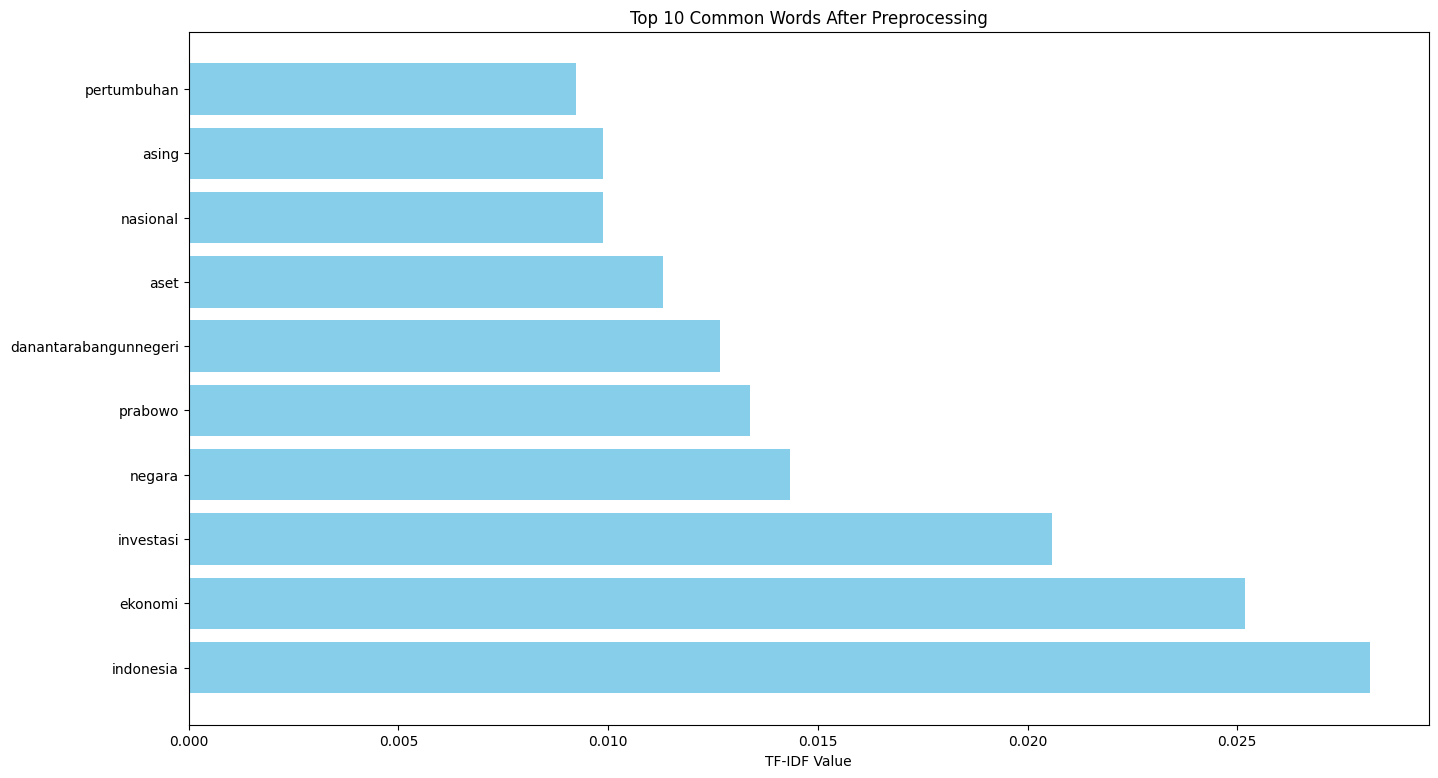

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# Mendapatkan daftar kata-kata dari TF-IDF Vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Menghitung nilai TF-IDF rata-rata untuk setiap kata
average_tfidf = tfidf_matrix.mean(axis=0).flatten()

# Membuat DataFrame untuk memudahkan pengurutan dan plotting
df2 = pd.DataFrame({'word': feature_names, 'tfidf': average_tfidf})

# Mengurutkan DataFrame berdasarkan nilai TF-IDF
df2 = df2.sort_values(by='tfidf', ascending=False)  # Change 'df' to 'df2'

# Mengambil 10 kata paling umum
top_10_words = df2.head(10)

# Plotting bar plot
plt.figure(figsize=(16, 9))
plt.barh(top_10_words['word'], top_10_words['tfidf'], color='skyblue')
plt.xlabel('TF-IDF Value')
plt.title('Top 10 Common Words After Preprocessing')
plt.show()

## Model Klasifikasi Dengan IndoBERT


In [30]:
#df.to_csv("C:/Uner/Organisasi/Iris/Project/Short trem 1_Danantara/data_bersih.csv", index= False)

In [31]:
print(type(preprocessed_texts), type(preprocessed_texts[0]))
print(preprocessed_texts[:5])


<class 'list'> <class 'str'>
['investasi negara terarah cerita buangbuang sumber daya danantarabangunnegeri terpercaya', 'alat pembangunan nasional jokowi mengawasi manfaatnya optimal bangsa danantarabangunnegeri terpercaya', 'mendorong ekonomi indonesia responsif adaptif danantarabangunnegeri terpercaya', 'sektor pendidikan worth', 'ekosistem investasi nasional inklusif mendukung inovasi berkelanjutan danantarabangunnegeri terpercaya']


In [32]:
import math
from tqdm import tqdm
import pandas as pd
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

model_name = "Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model     = AutoModelForSequenceClassification.from_pretrained(model_name)

nlp = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    return_all_scores=False
)

batch_size = 32
labels, scores = [], []

for i in tqdm(range(0, len(preprocessed_texts), batch_size), desc="Classifying"):
    batch = preprocessed_texts[i : i + batch_size]
    results = nlp(batch)
    labels.extend([r['label'] for r in results])
    scores.extend([r['score'] for r in results])

df['sentiment_label'] = labels
df['sentiment_score'] = scores



c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning:

`torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.

c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning:

`torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.

c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:896: FutureWarning:

`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.

c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\pipelines\text_classification.py:105: UserWarning:

`return_all_scores` is now deprecated,  if want

In [33]:
df.to_csv('C:/Uner/Organisasi/Iris/Project/Short trem 1_Danantara/sentiment1.csv', index=False)
print("Selesai! Hasil disimpan di sentiment.csv")

Selesai! Hasil disimpan di sentiment.csv


In [34]:
clean_df = pd.read_csv("C:/Uner/Organisasi/Iris/Project/Short trem 1_Danantara/sentiment.csv")

In [35]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32114 entries, 0 to 32113
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      32114 non-null  int64  
 1   created_at               32114 non-null  object 
 2   favorite_count           32114 non-null  int64  
 3   full_text                32114 non-null  object 
 4   id_str                   32114 non-null  int64  
 5   image_url                9007 non-null   object 
 6   in_reply_to_screen_name  17401 non-null  object 
 7   lang                     32114 non-null  object 
 8   location                 15852 non-null  object 
 9   quote_count              32114 non-null  int64  
 10  reply_count              32114 non-null  int64  
 11  retweet_count            32114 non-null  int64  
 12  tweet_url                32114 non-null  object 
 13  user_id_str              32114 non-null  int64  
 14  username              

In [36]:
clean_df["sentiment_label"].value_counts()

sentiment_label
Neutral     12861
Negative    12795
Positive     6458
Name: count, dtype: int64

In [37]:
clean_df["sentiment_score"].sum()/len(clean_df["sentiment_score"])

np.float64(0.9012246470335316)

### Visualisasi

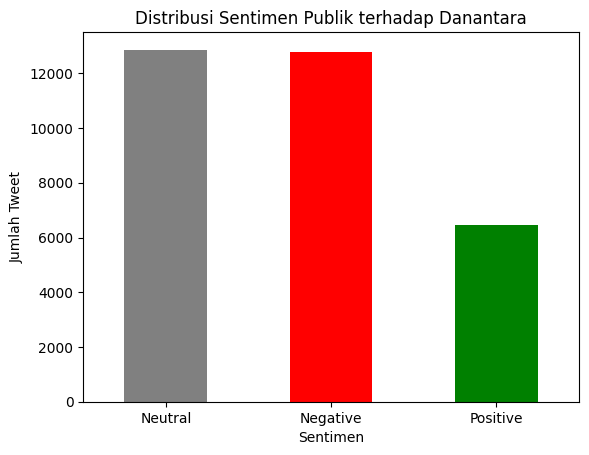

In [38]:
import matplotlib.pyplot as plt

clean_df['sentiment_label'].value_counts().plot(kind='bar', color=['gray', 'red', 'green'])
plt.title("Distribusi Sentimen Publik terhadap Danantara")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Tweet")
plt.xticks(rotation=0)
plt.show()


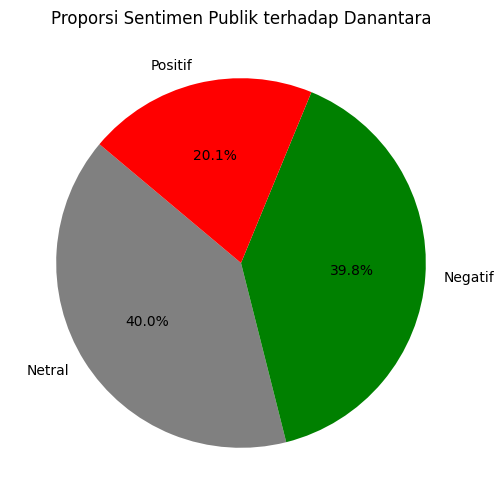

In [39]:
plt.figure(figsize=(6,6))
clean_df['sentiment_label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['gray', 'green', 'red'],
    labels=['Netral', 'Negatif', 'Positif'],
    startangle=140
)
plt.title("Proporsi Sentimen Publik terhadap Danantara")
plt.ylabel('')
plt.show()

In [40]:
all_words = " ".join(preprocessed_texts).split()
common_words = Counter(all_words).most_common(10)

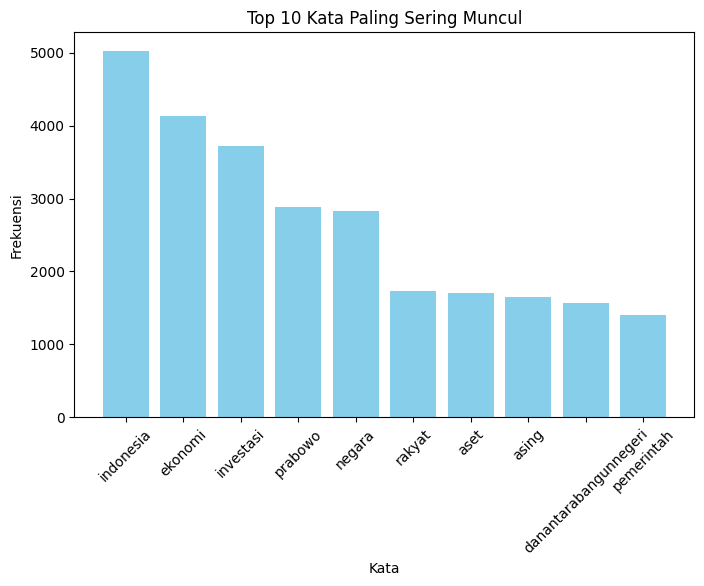

In [41]:
# Visualisasi
words, counts = zip(*common_words)
plt.figure(figsize=(8,5))
plt.bar(words, counts, color='skyblue')
plt.title("Top 10 Kata Paling Sering Muncul")
plt.xlabel("Kata")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45)
plt.show()

In [42]:
sentimen_labels = ['positif', 'netral', 'negatif']
colors = ['green', 'gray', 'red']

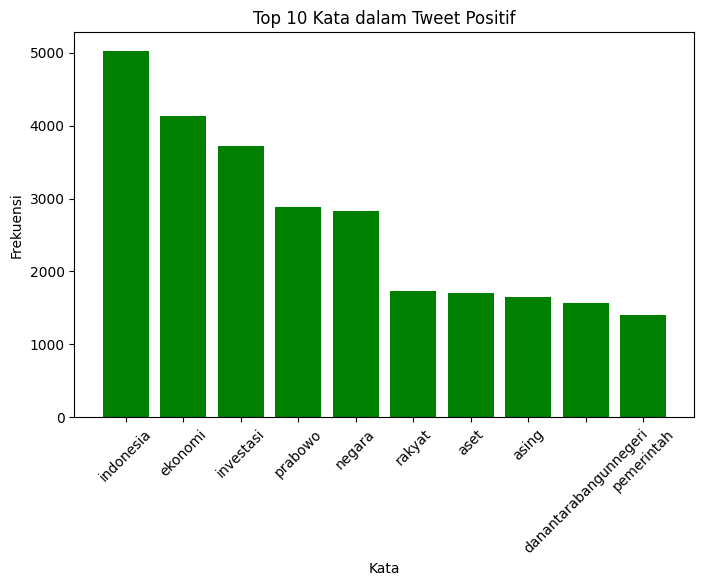

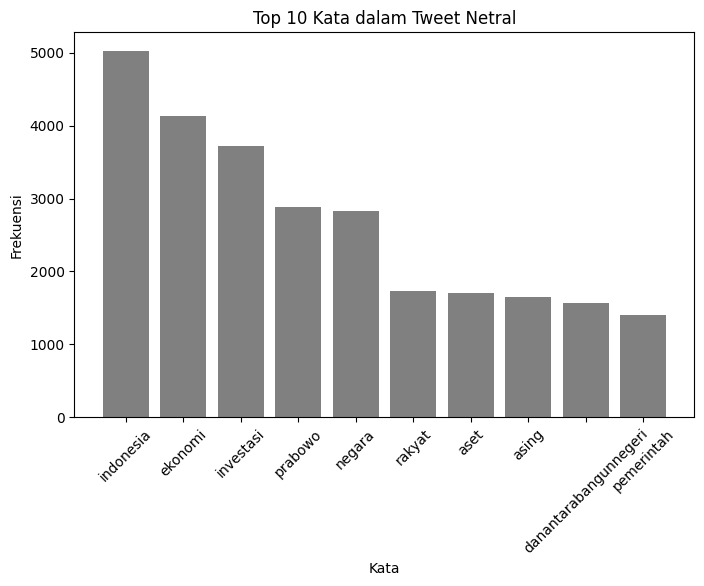

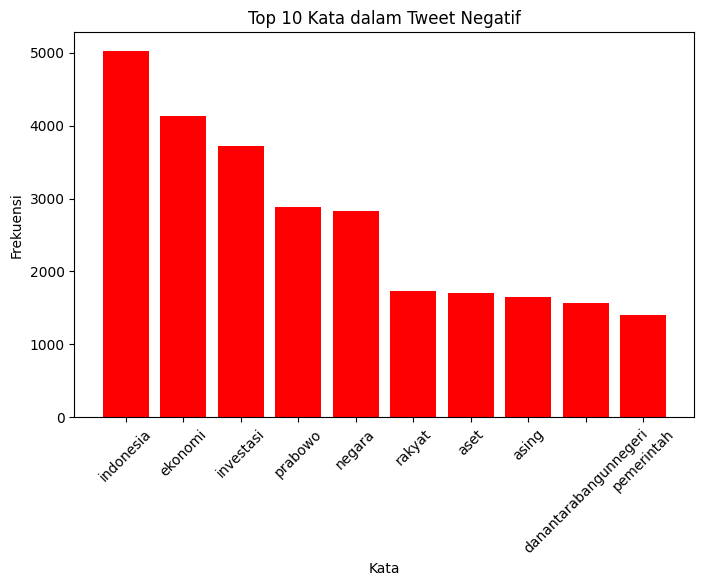

In [ ]:
for sentimen, color in zip(sentimen_labels, colors):
    subset = clean_df[clean_df["sentiment_label"] == sentimen]
    words = " ".join(preprocessed_texts).split()
    common_words = Counter(words).most_common(10)
    
    if common_words:
        kata, jumlah = zip(*common_words)
        plt.figure(figsize=(8,5))
        plt.bar(kata, jumlah, color=color)
        plt.title(f"Top 10 Kata dalam Tweet {sentimen.capitalize()}")
        plt.xlabel("Kata")
        plt.ylabel("Frekuensi")
        plt.xticks(rotation=45)
        plt.show()
    else:
        print(f"Tidak ada kata untuk label sentimen '{sentimen}'.")

### Clustering

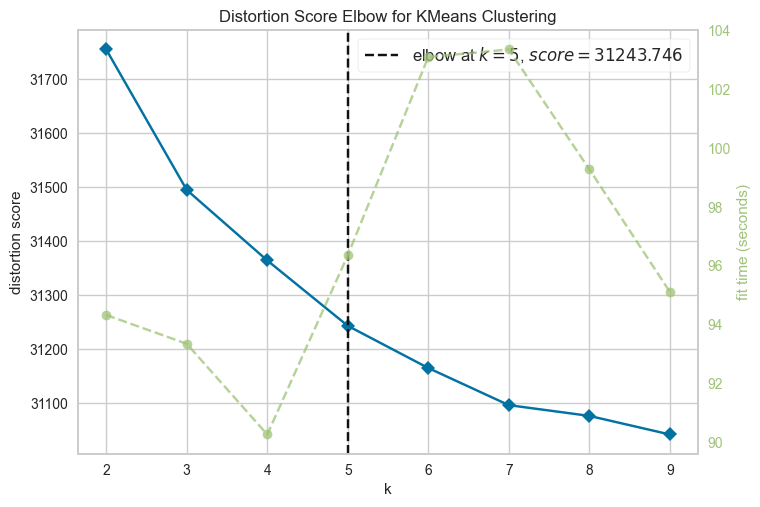

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [44]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt


from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()

# Define the K-Means model and K Elbow visualiser
model = KMeans(init='k-means++', random_state=42)  # Adjust random state if desired
visualizer = KElbowVisualizer(model, k=(2, 10))  # Adjust k range as needed

# Fit the data and visualize the elbow
visualizer.fit(tfidf_matrix)
visualizer.show()